# Load Curve Analysis

This notebook compares load curves from two different energy companies in different regions:

1. **South**: `Normaliserad typlastprofil branscher v. 1.csv` (Skövde region)
   - Columns: Hushåll (Housing), Tillverkning/SNI C (Industry), Service (Services)
   - Format: CSV with semicolon delimiter, comma decimals
   - 8784 rows (leap year 2024)

2. **West**: `TidsserierGE.xlsx` (Göteborg region)
   - Sheet: Sheet1
   - Columns: Hushåll, Tillverkning, Service
   - 8784 rows (leap year 2024)

## Goal

Extract comparable load curves for **housing**, **services**, and **industry** from both sources,
analyze how closely they overlap, and export normalized profiles as CSV files.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Set display options
pd.set_option('display.max_columns', 20)
pd.set_option('display.width', 200)

# Path to this folder and output directory
PROFILES_PATH = Path.cwd()
OUTPUT_PATH = PROFILES_PATH.parent  # Export to parent directory (load_curves/)
print(f"Working in: {PROFILES_PATH}")
print(f"Output to: {OUTPUT_PATH}")

# Configuration
DATA_YEAR = 2024
SEGMENTS = ['housing', 'services', 'industry']

Working in: /home/viktor/code/behovskartan/generator/input/load_profiles/energy_company_profiles
Output to: /home/viktor/code/behovskartan/generator/input/load_profiles


---

## Load South Region Data (Skövde)

In [2]:
# Load South (CSV with semicolon delimiter, comma decimals)
south_path = PROFILES_PATH / 'Normaliserad typlastprofil branscher v. 1.csv'

south_raw = pd.read_csv(
    south_path,
    sep=';',
    decimal=',',
    encoding='latin-1'  # Handle Swedish characters
)

print(f"South shape: {south_raw.shape}")
print(f"\nColumns: {list(south_raw.columns)}")
south_raw.head()

South shape: (8784, 4)

Columns: ['TIMESTAMPED', 'Hushåll', 'Tillverkning (SNI avd. C)', 'Service (SNI avd. D-K; M-N; S)']


,TIMESTAMPED,Hushåll,Tillverkning (SNI avd. C),Service (SNI avd. D-K; M-N; S)
0,2024-12-31 23:00,0.485561,0.216178,0.376977
1,2024-12-31 22:00,0.520870,0.219020,0.405564
2,2024-12-31 21:00,0.565991,0.227992,0.428153
3,2024-12-31 20:00,0.613900,0.231053,0.443934
4,2024-12-31 19:00,0.673750,0.231570,0.458485


In [3]:
# Parse timestamps and rename columns
south = south_raw.copy()

# Rename columns to standard names
column_map_south = {
    'TIMESTAMPED': 'timestamp',
    'Hushåll': 'housing',
    'Tillverkning (SNI avd. C)': 'industry',
    'Service (SNI avd. D-K; M-N; S)': 'services'
}

# Try to find matching columns (handle encoding variations)
for old_col in south.columns:
    for key, new_name in column_map_south.items():
        if key.lower() in old_col.lower() or old_col.lower() in key.lower():
            south = south.rename(columns={old_col: new_name})
            break

print("Renamed columns:", list(south.columns))

# Parse timestamp
if 'timestamp' in south.columns:
    south['timestamp'] = pd.to_datetime(south['timestamp'])
    south = south.sort_values('timestamp').reset_index(drop=True)

south.head()

Renamed columns: ['timestamp', 'housing', 'industry', 'services']


,timestamp,housing,industry,services
0,2024-01-01 00:00:00,0.548415,0.225430,0.432338
1,2024-01-01 01:00:00,0.539905,0.227478,0.433608
2,2024-01-01 02:00:00,0.526439,0.228452,0.429893
3,2024-01-01 03:00:00,0.508148,0.228753,0.426839
4,2024-01-01 04:00:00,0.494977,0.231451,0.431941


In [4]:
# Check timestamp range
if 'timestamp' in south.columns:
    print(f"Timestamp range: {south['timestamp'].min()} to {south['timestamp'].max()}")
    print(f"Total hours: {len(south)}")
    print(f"Expected for leap year: 8784")

Timestamp range: 2024-01-01 00:00:00 to 2024-12-31 23:00:00
Total hours: 8784
Expected for leap year: 8784


In [5]:
# Summary statistics for South
print("South Statistics:")
for col in SEGMENTS:
    if col in south.columns:
        print(f"\n{col}:")
        print(f"  Min: {south[col].min():.4f}")
        print(f"  Max: {south[col].max():.4f}")
        print(f"  Mean: {south[col].mean():.4f}")
        print(f"  Sum: {south[col].sum():.4f}")

South Statistics:

housing:
  Min: 0.1563
  Max: 1.0000
  Mean: 0.3901
  Sum: 3426.5447

services:
  Min: 0.2812
  Max: 1.0000
  Mean: 0.5182
  Sum: 4552.2672

industry:
  Min: 0.1793
  Max: 1.0000
  Mean: 0.5185
  Sum: 4554.1170


---

## Load West Region Data (Göteborg)

In [6]:
# Load West (Excel)
west_path = PROFILES_PATH / 'TidsserierGE.xlsx'

west_raw = pd.read_excel(west_path, sheet_name='Sheet1')

print(f"West shape: {west_raw.shape}")
print(f"\nColumns: {list(west_raw.columns)}")
west_raw.head(10)

West shape: (8784, 4)

Columns: ['Tidpunkt', 'Hushåll', 'Tillverkning', 'Service']


,Tidpunkt,Hushåll,Tillverkning,Service
0,2024-01-01 00:00,0.408924,0.068818,0.461642
1,2024-01-01 01:00,0.392205,0.081192,0.487864
2,2024-01-01 02:00,0.374980,0.099630,0.491131
3,2024-01-01 03:00,0.351288,0.096902,0.491251
4,2024-01-01 04:00,0.334618,0.091706,0.494454
5,2024-01-01 05:00,0.327936,0.088375,0.510235
6,2024-01-01 06:00,0.323252,0.122898,0.531019
7,2024-01-01 07:00,0.326275,0.133344,0.544083
8,2024-01-01 08:00,0.340588,0.140651,0.550943
9,2024-01-01 09:00,0.380173,0.151161,0.543508


In [7]:
# Map West columns to standard names
west = west_raw.copy()

column_map_west = {
    'Tidpunkt': 'timestamp',
    'Hushåll': 'housing',
    'Tillverkning': 'industry',
    'Service': 'services'
}

west = west.rename(columns=column_map_west)
print("Renamed columns:", list(west.columns))

# Parse timestamp
if 'timestamp' in west.columns:
    west['timestamp'] = pd.to_datetime(west['timestamp'])
    west = west.sort_values('timestamp').reset_index(drop=True)

west.head()

Renamed columns: ['timestamp', 'housing', 'industry', 'services']


,timestamp,housing,industry,services
0,2024-01-01 00:00:00,0.408924,0.068818,0.461642
1,2024-01-01 01:00:00,0.392205,0.081192,0.487864
2,2024-01-01 02:00:00,0.374980,0.099630,0.491131
3,2024-01-01 03:00:00,0.351288,0.096902,0.491251
4,2024-01-01 04:00:00,0.334618,0.091706,0.494454


In [8]:
# Summary statistics for West
print("West Statistics:")
for col in SEGMENTS:
    if col in west.columns:
        print(f"\n{col}:")
        print(f"  Min: {west[col].min():.4f}")
        print(f"  Max: {west[col].max():.4f}")
        print(f"  Mean: {west[col].mean():.4f}")
        print(f"  Sum: {west[col].sum():.4f}")

West Statistics:

housing:
  Min: 0.0000
  Max: 1.0000
  Mean: 0.2774
  Sum: 2436.9688

services:
  Min: 0.0000
  Max: 1.0000
  Mean: 0.3567
  Sum: 3133.1204

industry:
  Min: 0.0000
  Max: 1.0000
  Mean: 0.4310
  Sum: 3785.7015


---

## Normalize Profiles

Normalize both sets of profiles so they sum to 1.0 over the year.
This allows direct comparison regardless of the original scale.

In [9]:
def normalize_profile(series: pd.Series) -> pd.Series:
    """Normalize a profile to sum to 1.0"""
    return series / series.sum()

# Normalize South
south_norm = pd.DataFrame()
south_norm['timestamp'] = south['timestamp']
for col in SEGMENTS:
    if col in south.columns:
        south_norm[col] = normalize_profile(south[col])

print("South normalized (should all sum to 1.0):")
for col in SEGMENTS:
    if col in south_norm.columns:
        print(f"  {col}: {south_norm[col].sum():.6f}")

South normalized (should all sum to 1.0):
  housing: 1.000000
  services: 1.000000
  industry: 1.000000


In [10]:
# Normalize West
west_norm = pd.DataFrame()
west_norm['timestamp'] = west['timestamp']
for col in SEGMENTS:
    if col in west.columns:
        west_norm[col] = normalize_profile(west[col])

print("West normalized (should all sum to 1.0):")
for col in SEGMENTS:
    if col in west_norm.columns:
        print(f"  {col}: {west_norm[col].sum():.6f}")

West normalized (should all sum to 1.0):
  housing: 1.000000
  services: 1.000000
  industry: 1.000000


---

## Align Timeseries

Ensure both sources have the same number of hours and are aligned.
Handle differences in year (leap year vs non-leap year).

In [11]:
print(f"South length: {len(south_norm)}")
print(f"West length: {len(west_norm)}")

# Check if lengths match
if len(south_norm) == len(west_norm):
    print("\n✓ Same number of hours - can compare directly")
else:
    print(f"\n⚠️ Different lengths - need to align")
    print(f"  Difference: {abs(len(south_norm) - len(west_norm))} hours")

South length: 8784
West length: 8784

✓ Same number of hours - can compare directly


In [12]:
def align_to_8760(df: pd.DataFrame) -> pd.DataFrame:
    """
    Align a dataframe to 8760 hours (non-leap year).
    If 8784 hours, remove Feb 29.
    """
    if len(df) == 8760:
        return df.copy()
    elif len(df) == 8784:
        # Remove Feb 29 (hours 1416-1439, i.e., day 59)
        mask = ~((df.index >= 1416) & (df.index < 1440))
        result = df.loc[mask].reset_index(drop=True)
        return result
    else:
        print(f"Warning: unexpected length {len(df)}")
        return df.copy()

# Align both sources to 8760 hours
south_aligned = align_to_8760(south_norm)
west_aligned = align_to_8760(west_norm)

print(f"South aligned: {len(south_aligned)} hours")
print(f"West aligned: {len(west_aligned)} hours")

South aligned: 8760 hours
West aligned: 8760 hours


---

## Compare Profiles

Visualize and quantify differences between the two sources.

In [13]:
def calculate_comparison_metrics(s1: pd.Series, s2: pd.Series) -> dict:
    """Calculate comparison metrics between two profiles."""
    if len(s1) != len(s2):
        return {'error': 'Length mismatch'}
    
    return {
        'correlation': s1.corr(s2),
        'rmse': np.sqrt(((s1 - s2) ** 2).mean()),
        'mae': (s1 - s2).abs().mean(),
        'max_diff': (s1 - s2).abs().max(),
        'mean_south': s1.mean(),
        'mean_west': s2.mean(),
        'std_south': s1.std(),
        'std_west': s2.std(),
    }

# Compare each segment
print("Comparison Metrics (normalized profiles):")
print("=" * 60)

for segment in SEGMENTS:
    if segment in south_aligned.columns and segment in west_aligned.columns:
        metrics = calculate_comparison_metrics(
            south_aligned[segment],
            west_aligned[segment]
        )
        print(f"\n{segment.upper()}:")
        for key, value in metrics.items():
            if isinstance(value, float):
                print(f"  {key}: {value:.6f}")
            else:
                print(f"  {key}: {value}")

Comparison Metrics (normalized profiles):

HOUSING:
  correlation: 0.980208
  rmse: 0.000029
  mae: 0.000024
  max_diff: 0.000131
  mean_south: 0.000114
  mean_west: 0.000114
  std_south: 0.000044
  std_west: 0.000071

SERVICES:
  correlation: 0.791080
  rmse: 0.000048
  mae: 0.000042
  max_diff: 0.000125
  mean_south: 0.000114
  mean_west: 0.000114
  std_south: 0.000032
  std_west: 0.000069

INDUSTRY:
  correlation: 0.883020
  rmse: 0.000026
  mae: 0.000021
  max_diff: 0.000097
  mean_south: 0.000114
  mean_west: 0.000114
  std_south: 0.000047
  std_west: 0.000056


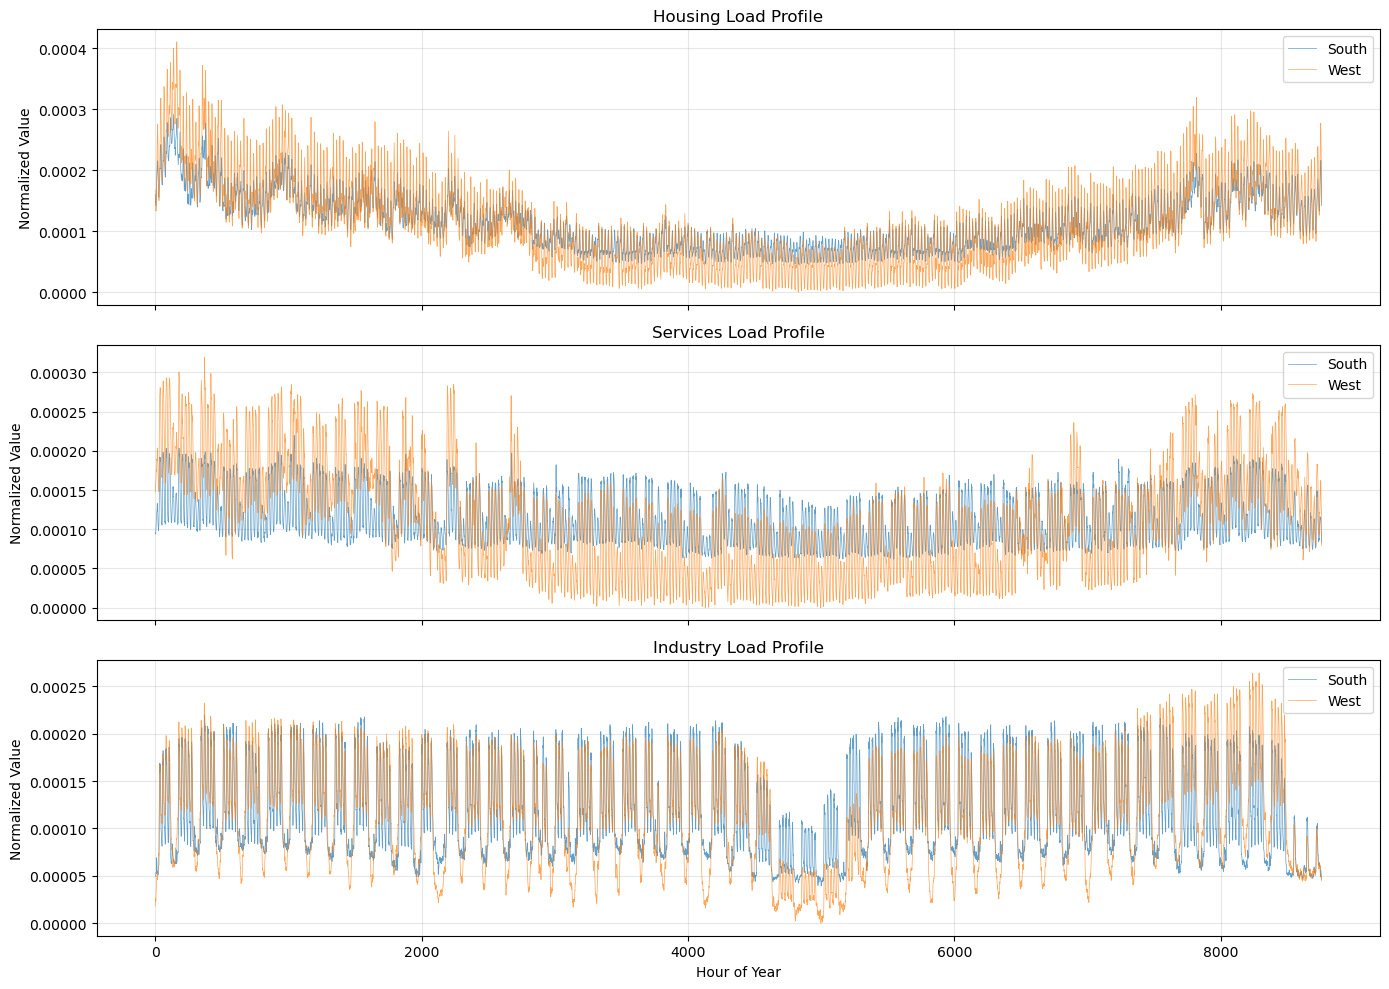

In [14]:
# Visual comparison - full year
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, segment in enumerate(SEGMENTS):
    ax = axes[i]
    
    if segment in south_aligned.columns:
        ax.plot(south_aligned[segment].values, label='South', alpha=0.7, linewidth=0.5)
    if segment in west_aligned.columns:
        ax.plot(west_aligned[segment].values, label='West', alpha=0.7, linewidth=0.5)
    
    ax.set_ylabel('Normalized Value')
    ax.set_title(f'{segment.title()} Load Profile')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Hour of Year')
plt.tight_layout()
plt.show()

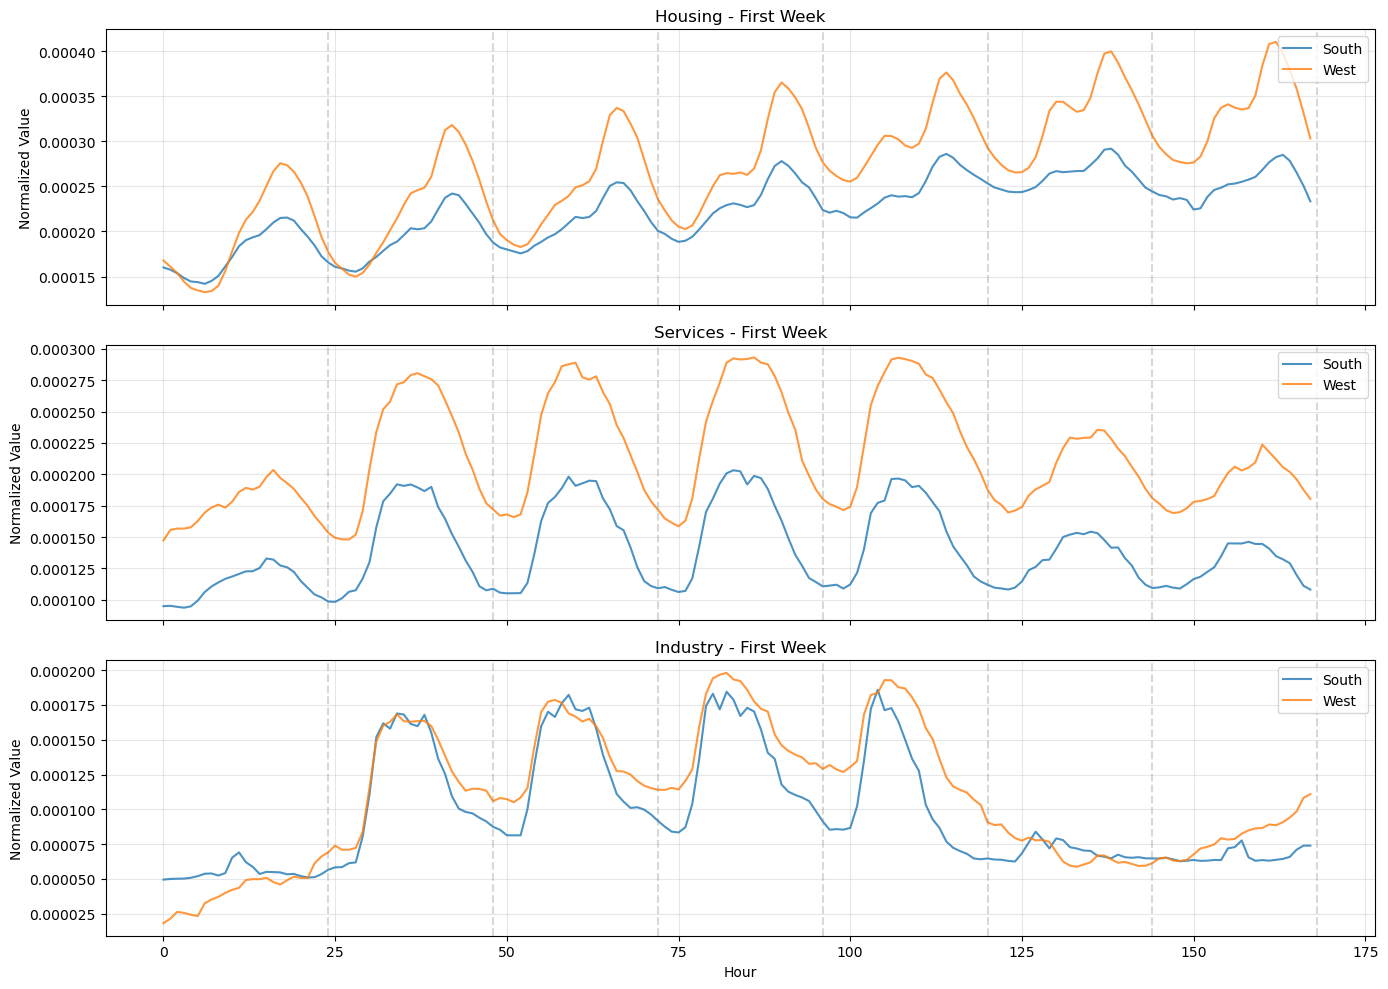

In [15]:
# Visual comparison - typical week (first week of January)
week_hours = 168  # 7 days * 24 hours

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, segment in enumerate(SEGMENTS):
    ax = axes[i]
    
    if segment in south_aligned.columns:
        ax.plot(south_aligned[segment].iloc[:week_hours].values, label='South', alpha=0.8)
    if segment in west_aligned.columns:
        ax.plot(west_aligned[segment].iloc[:week_hours].values, label='West', alpha=0.8)
    
    ax.set_ylabel('Normalized Value')
    ax.set_title(f'{segment.title()} - First Week')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    
    # Add day markers
    for d in range(1, 8):
        ax.axvline(x=d*24, color='gray', linestyle='--', alpha=0.3)

axes[-1].set_xlabel('Hour')
plt.tight_layout()
plt.show()

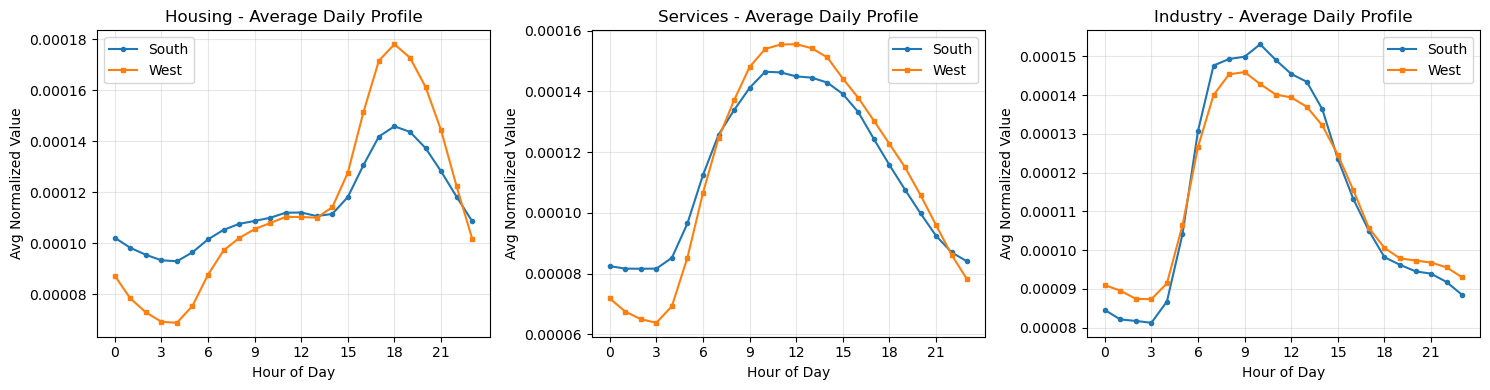

In [16]:
# Average daily profile comparison
def get_average_daily_profile(df: pd.DataFrame, segment: str) -> pd.Series:
    """Calculate average hourly values across all days."""
    if segment not in df.columns:
        return pd.Series()
    
    values = df[segment].values
    # Reshape to (days, 24) and take mean
    n_days = len(values) // 24
    reshaped = values[:n_days*24].reshape(n_days, 24)
    return pd.Series(reshaped.mean(axis=0), name=segment)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, segment in enumerate(SEGMENTS):
    ax = axes[i]
    
    daily_south = get_average_daily_profile(south_aligned, segment)
    daily_west = get_average_daily_profile(west_aligned, segment)
    
    if len(daily_south) > 0:
        ax.plot(daily_south.values, label='South', marker='o', markersize=3)
    if len(daily_west) > 0:
        ax.plot(daily_west.values, label='West', marker='s', markersize=3)
    
    ax.set_xlabel('Hour of Day')
    ax.set_ylabel('Avg Normalized Value')
    ax.set_title(f'{segment.title()} - Average Daily Profile')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xticks(range(0, 24, 3))

plt.tight_layout()
plt.show()

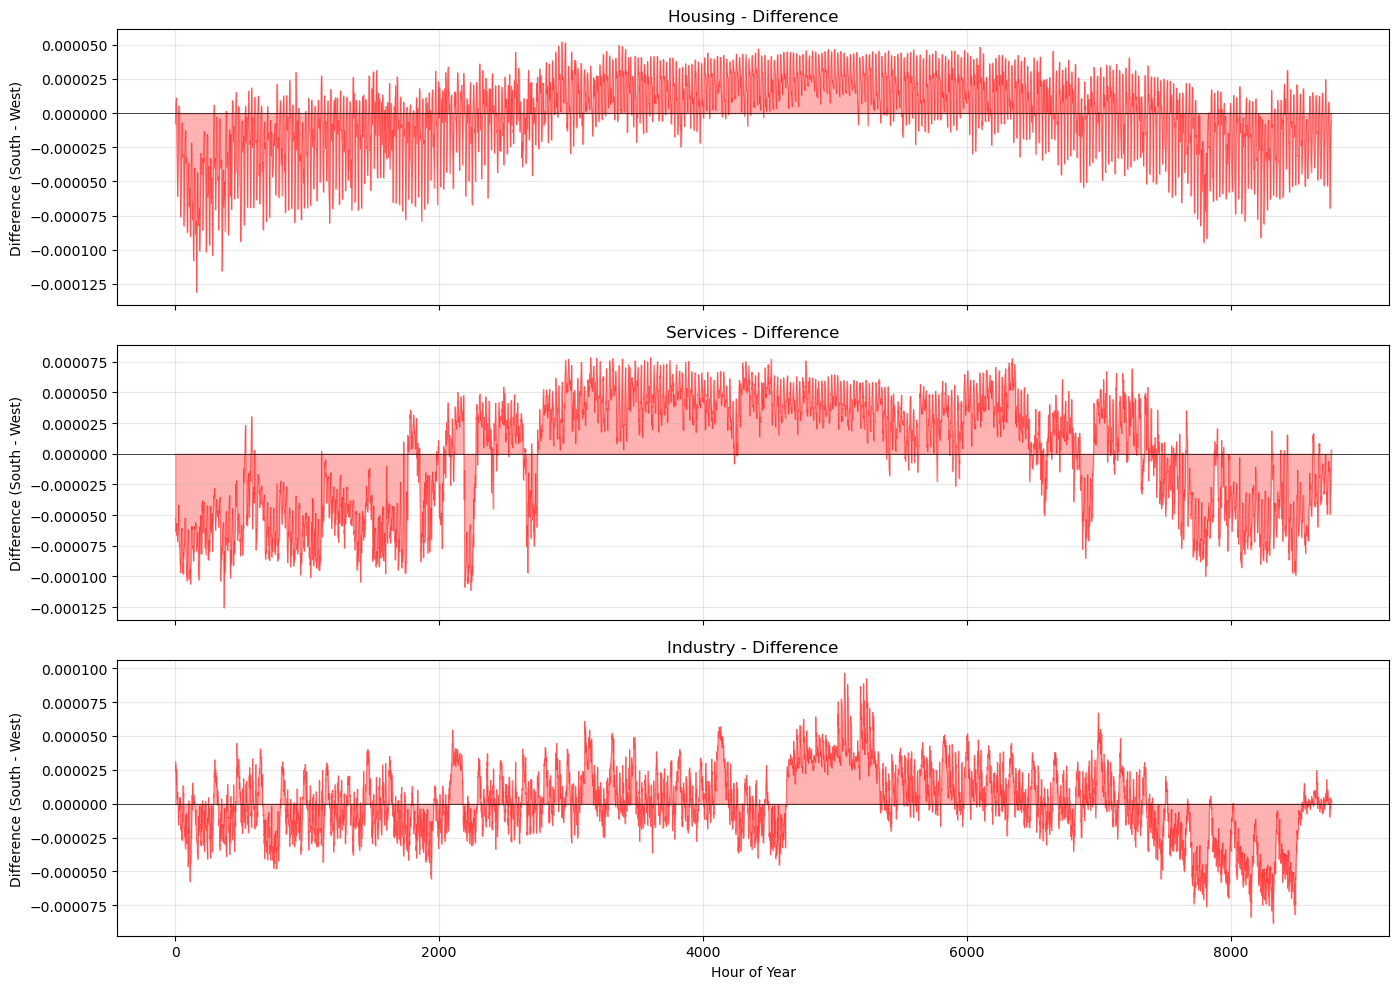

In [17]:
# Difference analysis
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for i, segment in enumerate(SEGMENTS):
    ax = axes[i]
    
    if segment in south_aligned.columns and segment in west_aligned.columns:
        diff = south_aligned[segment] - west_aligned[segment]
        ax.plot(diff.values, color='red', alpha=0.5, linewidth=0.5)
        ax.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        ax.fill_between(range(len(diff)), diff.values, 0, alpha=0.3, color='red')
    
    ax.set_ylabel('Difference (South - West)')
    ax.set_title(f'{segment.title()} - Difference')
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Hour of Year')
plt.tight_layout()
plt.show()

---

## Seasonal Analysis

Compare profiles across different seasons.

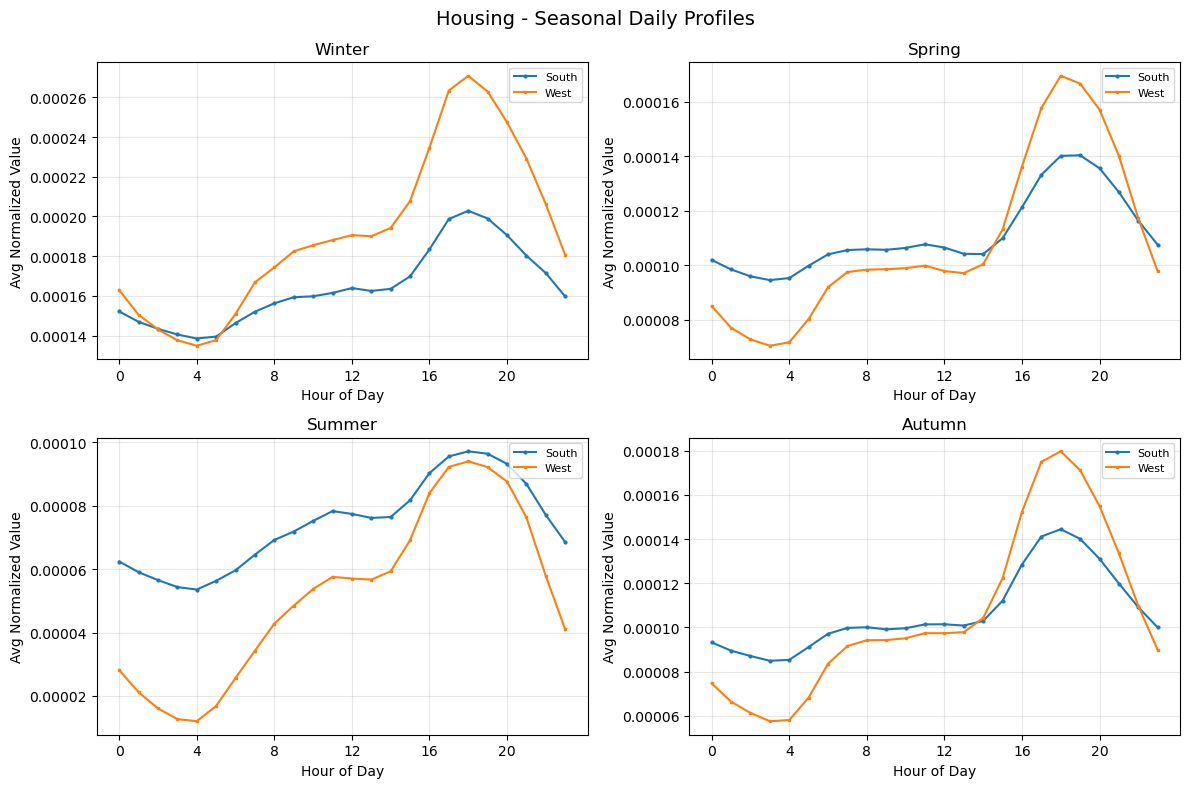

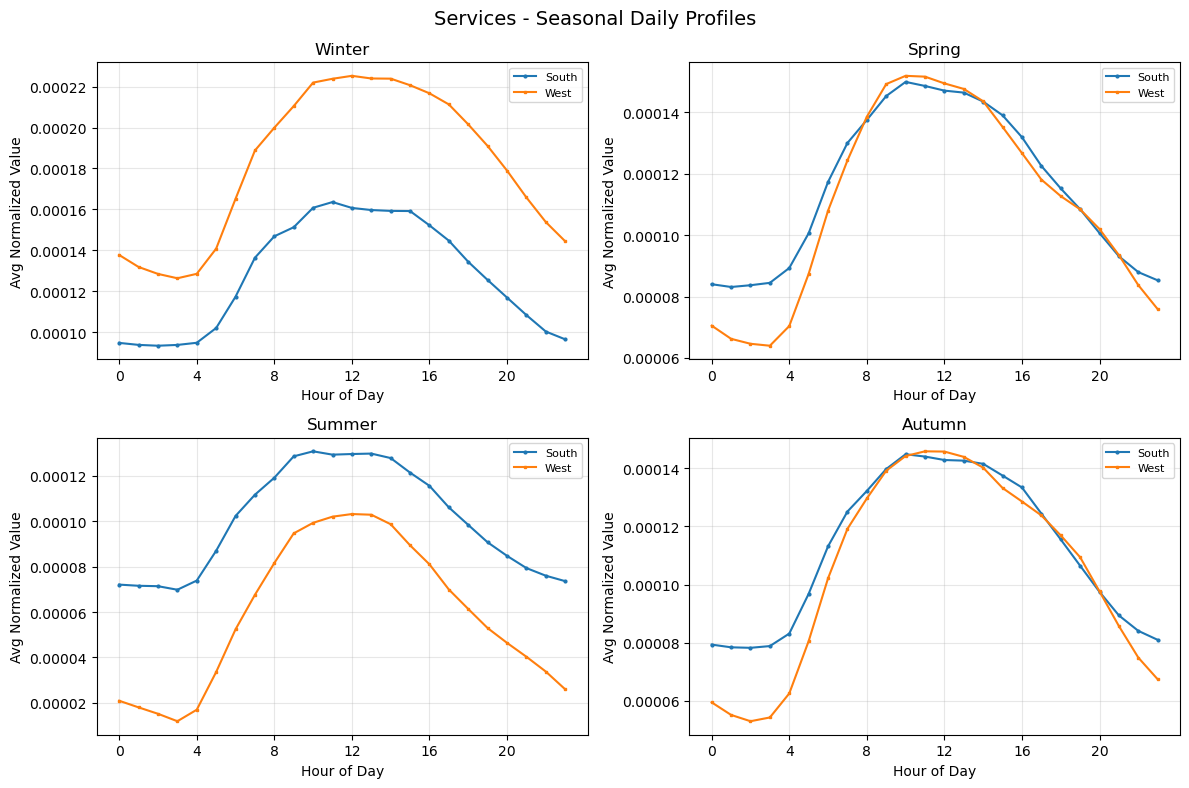

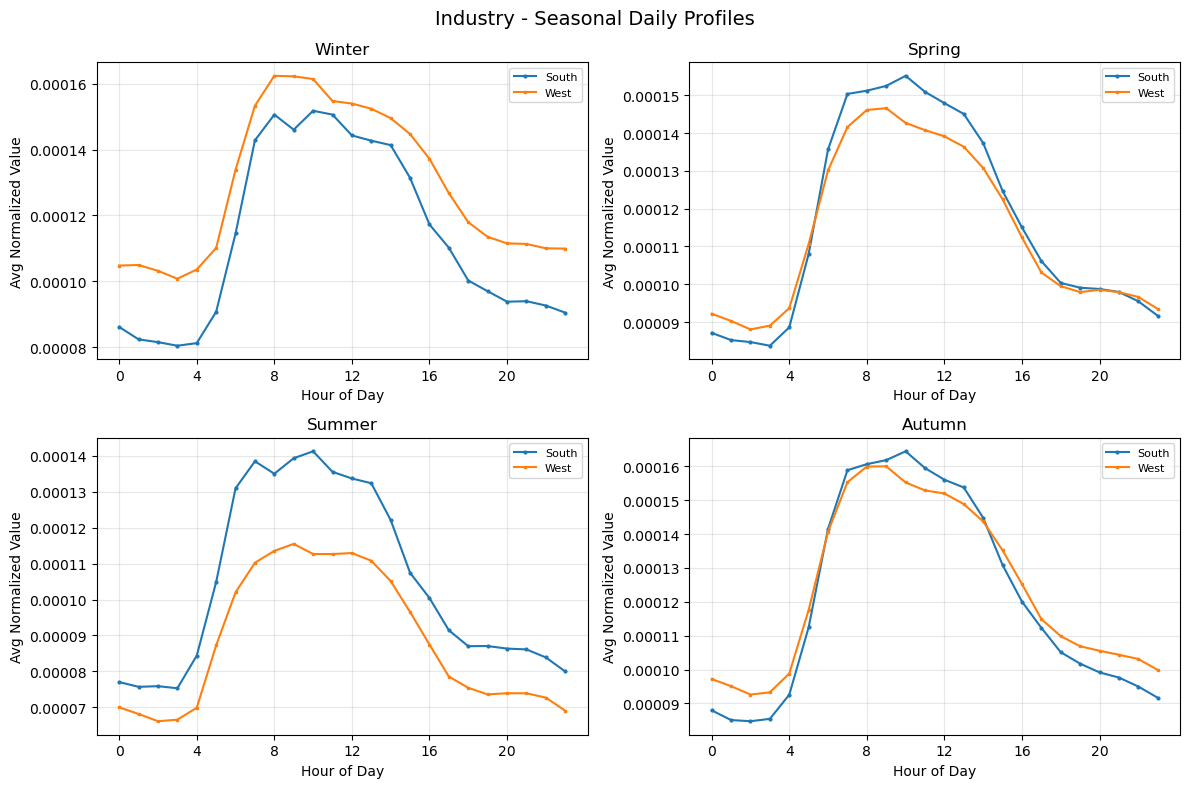

In [18]:
def get_seasonal_profiles(df: pd.DataFrame, segment: str) -> dict:
    """Extract average daily profiles by season."""
    if segment not in df.columns:
        return {}
    
    values = df[segment].values
    
    # Season boundaries (approximate for 8760 hours)
    seasons = {
        'winter': np.concatenate([values[0:1416], values[8016:8760]]),
        'spring': values[1416:3624],
        'summer': values[3624:5832],
        'autumn': values[5832:8016]
    }
    
    result = {}
    for season, data in seasons.items():
        n_days = len(data) // 24
        if n_days > 0:
            reshaped = data[:n_days*24].reshape(n_days, 24)
            result[season] = reshaped.mean(axis=0)
    
    return result

# Plot seasonal comparison for each segment
for segment in SEGMENTS:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(f'{segment.title()} - Seasonal Daily Profiles', fontsize=14)
    
    seasonal_south = get_seasonal_profiles(south_aligned, segment)
    seasonal_west = get_seasonal_profiles(west_aligned, segment)
    
    for i, (season, ax) in enumerate(zip(['winter', 'spring', 'summer', 'autumn'], axes.flat)):
        if season in seasonal_south:
            ax.plot(seasonal_south[season], label='South', marker='o', markersize=2)
        if season in seasonal_west:
            ax.plot(seasonal_west[season], label='West', marker='s', markersize=2)
        
        ax.set_title(season.title())
        ax.set_xlabel('Hour of Day')
        ax.set_ylabel('Avg Normalized Value')
        ax.legend(loc='upper right', fontsize=8)
        ax.grid(True, alpha=0.3)
        ax.set_xticks(range(0, 24, 4))
    
    plt.tight_layout()
    plt.show()

---

## Conclusions and Recommendations

In [19]:
# Summary table
print("LOAD CURVE COMPARISON SUMMARY")
print("=" * 70)
print(f"{'Segment':<15} {'Correlation':<12} {'RMSE':<12} {'MAE':<12} {'Max Diff':<12}")
print("-" * 70)

for segment in SEGMENTS:
    if segment in south_aligned.columns and segment in west_aligned.columns:
        metrics = calculate_comparison_metrics(
            south_aligned[segment],
            west_aligned[segment]
        )
        print(f"{segment:<15} {metrics['correlation']:<12.4f} {metrics['rmse']:<12.6f} {metrics['mae']:<12.6f} {metrics['max_diff']:<12.6f}")

print("=" * 70)
print("\nInterpretation:")
print("- Correlation > 0.95: Very similar profiles")
print("- Correlation 0.90-0.95: Similar with some differences")
print("- Correlation < 0.90: Significantly different profiles")

LOAD CURVE COMPARISON SUMMARY
Segment         Correlation  RMSE         MAE          Max Diff    
----------------------------------------------------------------------
housing         0.9802       0.000029     0.000024     0.000131    
services        0.7911       0.000048     0.000042     0.000125    
industry        0.8830       0.000026     0.000021     0.000097    

Interpretation:
- Correlation > 0.95: Very similar profiles
- Correlation 0.90-0.95: Similar with some differences
- Correlation < 0.90: Significantly different profiles


### Notes and Decisions

*Add your conclusions here after running the analysis:*

1. **Housing profiles**: [similarity assessment]
2. **Services profiles**: [similarity assessment]
3. **Industry profiles**: [similarity assessment]

**Recommended action**: [which source to use, or average, or other approach]

---

## Export Profiles to CSV

Export normalized profiles as CSV files for use in the generator.

**File naming convention**: `profile_{area}_{segment}_{year}.csv`

Each file contains:
- `hour`: Hour index (0-8759)
- `value`: Normalized value (sums to 1.0 over the year)

In [20]:
def export_profile_csv(df: pd.DataFrame, segment: str, area: str, year: int, output_path: Path) -> Path:
    """
    Export a single normalized profile to CSV.
    
    Parameters:
    - df: DataFrame with normalized segment column
    - segment: Segment name (housing, services, industry)
    - area: Geographic area (south, west)
    - year: Data year
    - output_path: Directory to save files
    
    Returns:
    - Path to created file
    """
    if segment not in df.columns:
        raise ValueError(f"Segment '{segment}' not found in DataFrame")
    
    # Create export DataFrame
    export_df = pd.DataFrame({
        'hour': range(len(df)),
        'value': df[segment].values
    })
    
    # Generate filename
    filename = f"profile_{segment}_{area}_{year}.csv"
    filepath = output_path / filename
    
    # Export to CSV
    export_df.to_csv(filepath, index=False)
    
    # Verify sum
    total = export_df['value'].sum()
    print(f"Exported: {filename} (sum={total:.6f}, rows={len(export_df)})")
    
    return filepath


def export_all_profiles(south_df: pd.DataFrame, west_df: pd.DataFrame, 
                        segments: list, year: int, output_path: Path) -> list:
    """
    Export all profiles for both areas.
    
    Returns list of created file paths.
    """
    created_files = []
    
    print(f"\nExporting profiles to: {output_path}")
    print("=" * 50)
    
    # Export South profiles
    print("\nSouth profiles:")
    for segment in segments:
        if segment in south_df.columns:
            filepath = export_profile_csv(south_df, segment, 'south', year, output_path)
            created_files.append(filepath)
    
    # Export West profiles
    print("\nWest profiles:")
    for segment in segments:
        if segment in west_df.columns:
            filepath = export_profile_csv(west_df, segment, 'west', year, output_path)
            created_files.append(filepath)
    
    print("\n" + "=" * 50)
    print(f"Total files created: {len(created_files)}")
    
    return created_files

In [21]:
# Export all profiles to parent directory (load_curves/)
exported_files = export_all_profiles(
    south_df=south_aligned,
    west_df=west_aligned,
    segments=SEGMENTS,
    year=DATA_YEAR,
    output_path=OUTPUT_PATH
)


Exporting profiles to: /home/viktor/code/behovskartan/generator/input/load_profiles

South profiles:
Exported: profile_housing_south_2024.csv (sum=0.996819, rows=8760)
Exported: profile_services_south_2024.csv (sum=0.996865, rows=8760)
Exported: profile_industry_south_2024.csv (sum=0.996487, rows=8760)

West profiles:
Exported: profile_housing_west_2024.csv (sum=0.996073, rows=8760)
Exported: profile_services_west_2024.csv (sum=0.994984, rows=8760)
Exported: profile_industry_west_2024.csv (sum=0.996170, rows=8760)

Total files created: 6


In [22]:
# Verify exported files
print("\nVerifying exported files:")
print("-" * 50)

for filepath in exported_files:
    if filepath.exists():
        df = pd.read_csv(filepath)
        print(f"{filepath.name}:")
        print(f"  Rows: {len(df)}, Sum: {df['value'].sum():.6f}")
        print(f"  Min: {df['value'].min():.6f}, Max: {df['value'].max():.6f}")


Verifying exported files:
--------------------------------------------------
profile_housing_south_2024.csv:
  Rows: 8760, Sum: 0.996819
  Min: 0.000046, Max: 0.000292
profile_services_south_2024.csv:
  Rows: 8760, Sum: 0.996865
  Min: 0.000062, Max: 0.000220
profile_industry_south_2024.csv:
  Rows: 8760, Sum: 0.996487
  Min: 0.000039, Max: 0.000220
profile_housing_west_2024.csv:
  Rows: 8760, Sum: 0.996073
  Min: 0.000000, Max: 0.000410
profile_services_west_2024.csv:
  Rows: 8760, Sum: 0.994984
  Min: 0.000000, Max: 0.000319
profile_industry_west_2024.csv:
  Rows: 8760, Sum: 0.996170
  Min: 0.000000, Max: 0.000264


In [23]:
# List all exported files in parent directory
print("\nExported profile files:")
for f in sorted(OUTPUT_PATH.glob('profile_*.csv')):
    print(f"  {f.name}")


Exported profile files:
  profile_housing_south_2024.csv
  profile_housing_west_2024.csv
  profile_industry_south_2024.csv
  profile_industry_west_2024.csv
  profile_services_south_2024.csv
  profile_services_west_2024.csv
  profile_transport_cars_2024.csv
  profile_transport_rail_2024.csv
  profile_transport_rail_flat_2024.csv
  profile_transport_trucks_2024.csv
